In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day25-normalization/wine_data.csv"

df = pd.read_csv(url, header=None, usecols=[0, 1, 2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

df.sample(5)

,Class label,Alcohol,Malic acid
33,1,13.76,1.53
46,1,14.38,3.59
93,2,12.29,2.83
171,3,12.77,2.39
28,1,13.87,1.90


<Axes: xlabel='Alcohol', ylabel='Density'>

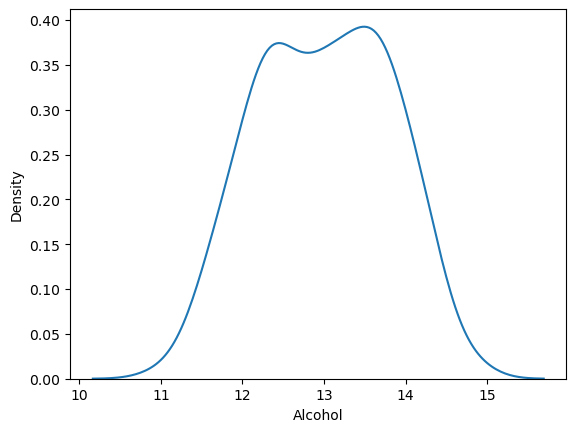

In [3]:
sns.kdeplot(data=df,x='Alcohol')

<Axes: xlabel='Malic acid', ylabel='Density'>

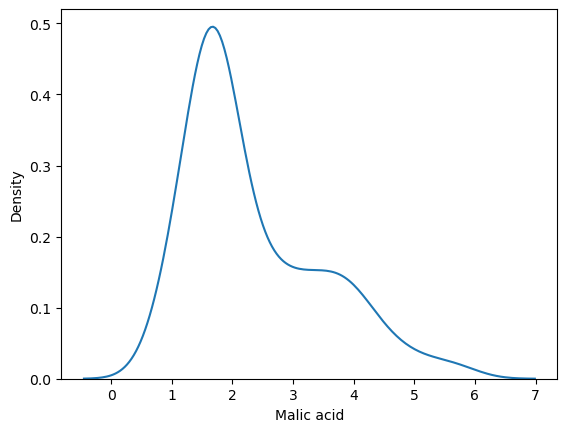

In [15]:
sns.kdeplot(data=df,x='Malic acid')

In [40]:
from sklearn.model_selection import train_test_split
x = df.drop('Class label', axis=1) 
y = df['Class label']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=23)

x_train.shape, x_test.shape

((142, 2), (36, 2))

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()  

scaler.fit(x_train) 

x_train_scaled = scaler.transform(x_train) 
x_test_scaled = scaler.transform(x_test)  

In [49]:
print(scaler.data_min_)
print(scaler.data_max_)

[11.03  0.74]
[14.83  5.8 ]


In [50]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns )
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns) # for to convert into df 

In [51]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [52]:
np.round(x_train.describe(),1)

,Alcohol,Malic acid
count,142.0,142.0
mean,13.0,2.3
std,0.8,1.1
min,11.0,0.7
25%,12.4,1.6
50%,13.0,1.9
75%,13.7,3.1
max,14.8,5.8


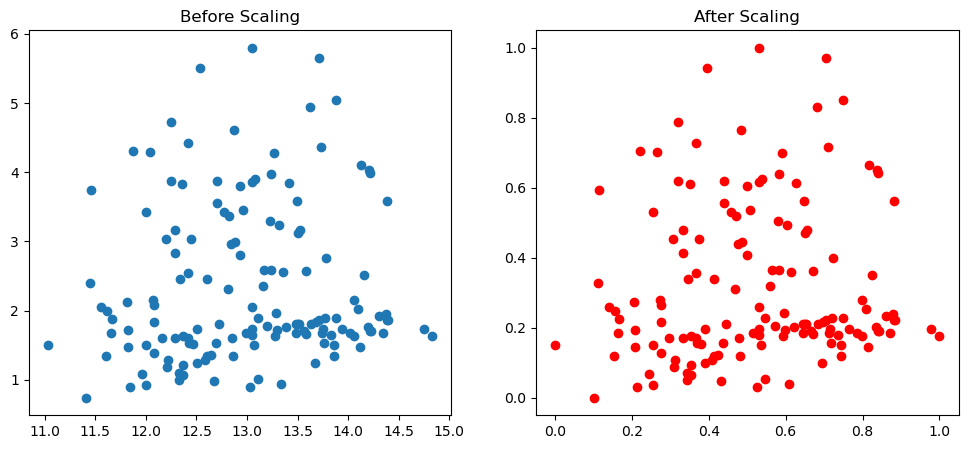

In [54]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Alcohol'], x_train['Malic acid'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'],color='red')
ax2.set_title("After Scaling")
plt.show()   # distribution remain same only change scale